In [1]:
from pathlib import Path
import contextlib

import pandas as pd
from val_utils import compute_stats
from val_utils import plot_compass_confusion_matrix_from_data

import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

In [2]:
results_fp = Path("./results/solar_extraction_aug_2025.csv").resolve()
out_dir = results_fp.parent
plots_out_dir = out_dir / "plots"
plots_out_dir.mkdir(exist_ok=True)

In [3]:
results = pd.read_csv(results_fp)

In [4]:
results["Score"] = results.Score.map(
    {
        10675893: "Correct (DNE)",
        7592334: "Correct (exists)",
        14791492: "Intern value wrong, LLM correct",
        13463000: "Intern value wrong, LLM wrong also",
        931198: "Value does not exist but LLM reported it",
        3305961: "Value exists but LLM did not find",
        238: "Value exists but LLM got it wrong",
        49407: "Bad web scrape",
        6684927: "Still bad scrape (missing)",
        1193229: "No doc now good scrape",
        7348600: "Still bad scrape (content)"
    }
)
results["Score"].value_counts()

Score
Correct (DNE)                               1088
No doc now good scrape                       644
Correct (exists)                             404
Intern value wrong, LLM correct               62
Value exists but LLM did not find             52
Still bad scrape (missing)                    23
Value does not exist but LLM reported it      17
Value exists but LLM got it wrong              8
Intern value wrong, LLM wrong also             2
Name: count, dtype: int64

In [5]:
correct_doc_compare = results[
    ~results["Score"].isin(
        {
            "Bad web scrape",
            "Still bad scrape (missing)",
            "No doc now good scrape",
            "Still bad scrape (content)",
        }
    )
].copy()

In [6]:
len(correct_doc_compare.groupby(
    ["county", "state", "subdivision", "jurisdiction_type"],
    dropna=False
))

71

In [7]:
exist_cats = {
    "Correct (exists)",
    "Intern value wrong, LLM correct",
    "Intern value wrong, LLM wrong also",
    "Value exists but LLM did not find",
    "Value exists but LLM got it wrong",
}

correct_doc_compare["ordinance_value_exists"] = (
    correct_doc_compare["Score"].apply(
        lambda x: int(x in exist_cats)
    )
)

correct_doc_compare["ordinance_value_exists"].value_counts()

ordinance_value_exists
0    1105
1     528
Name: count, dtype: int64

In [8]:
score_cats = {
    "dne_no_report": {
        "Correct (DNE)",
        # "Intern value wrong, LLM correct"
    },
    "exists_report": {
        "Correct (exists)",
        "Intern value wrong, LLM correct",
    },
    "dne_report": {"Value does not exist but LLM reported it"},
    "exists_bad_report": {
        "Intern value wrong, LLM wrong also",
        "Value exists but LLM got it wrong"
    },
    "exists_no_report": {"Value exists but LLM did not find"},
}

In [9]:
truth_labels_col = "ordinance_value_exists"

out = compute_stats(
    correct_doc_compare,
    score_cats,
    truth_labels_col=truth_labels_col,
)
compass_cm, compass_acc, compass_precision, compass_recall, compass_f1 = out


print("COMPASS")
print("confusion matrix:\n", compass_cm)
print(
    f"accuracy={compass_acc:.2%}, "
    f"precision={compass_precision:.2%}, "
    f"recall={compass_recall:.2%}, "
    f"F1={compass_f1:.2%}"
)

COMPASS
confusion matrix:
 [[ 466   62]
 [  17 1088]]
accuracy=95.16%, precision=94.52%, recall=88.26%, F1=91.28%


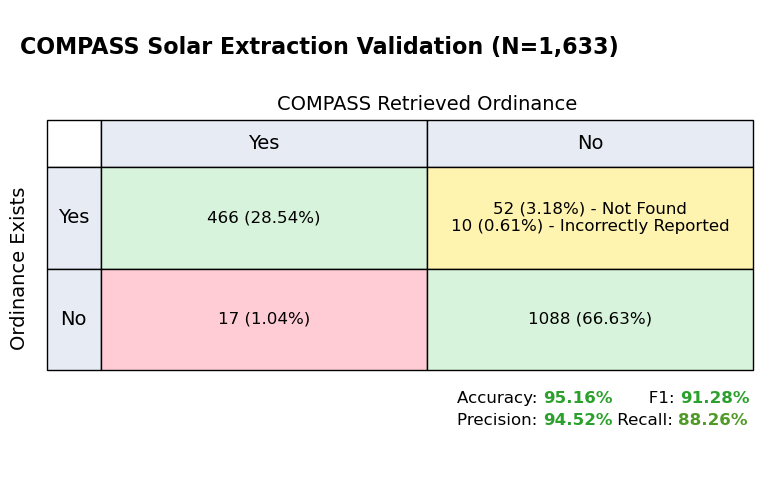

In [10]:
plot_compass_confusion_matrix_from_data(
    correct_doc_compare,
    score_cats,
    title="COMPASS Solar Extraction Validation",
    truth_labels_col=truth_labels_col,
    x_label="COMPASS Retrieved Ordinance",
    y_label="Ordinance Exists",
    out_fp=plots_out_dir / "solar_validation_all_ordinances.png",
    color_scores=True,
)

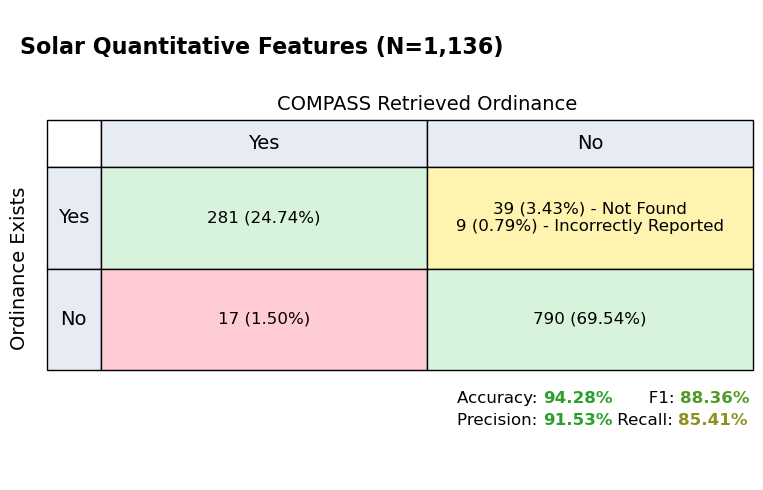

In [11]:
quant_feats = {
    "structures (participating)",
    "property line (participating)",
    "structures (non-participating)",
    "property line (non-participating)",
    "roads",
    "railroads",
    "transmission",
    "water",
    "noise",
    "maximum height",
    "maximum project size",
    "minimum lot size",
    "maximum lot size",
    "density",
    "coverage",
    "year",
}

plot_compass_confusion_matrix_from_data(
    correct_doc_compare[correct_doc_compare["feature"].isin(quant_feats)],
    score_cats,
    title="Solar Quantitative Features",
    truth_labels_col=truth_labels_col,
    out_fp=plots_out_dir / "solar_validation_quant.png",
    color_scores=True,
)

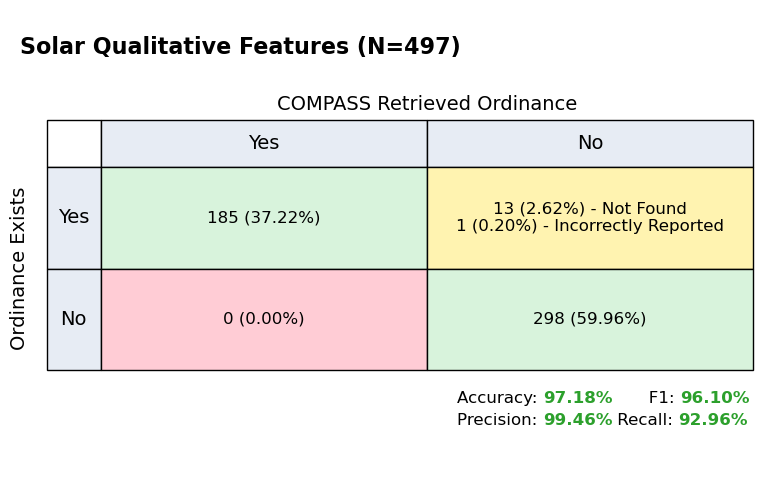

In [12]:
plot_compass_confusion_matrix_from_data(
    correct_doc_compare[~correct_doc_compare["feature"].isin(quant_feats)],
    score_cats,
    title="Solar Qualitative Features",
    truth_labels_col=truth_labels_col,
    out_fp=plots_out_dir / "solar_validation_qual.png",
    color_scores=True,
)

In [13]:
all_stats = []
for feature in correct_doc_compare["feature"].unique():
    data = correct_doc_compare[correct_doc_compare["feature"] == feature]
    __, a, p, r, f1 = compute_stats(
        data, score_cats, truth_labels_col=truth_labels_col
    )
    num_values = data["ordinance_value_exists"].sum()
    num_found = (
        data["Score"].isin(
            score_cats["exists_report"]
            | score_cats["exists_bad_report"]
            | score_cats["dne_report"]
        )
    ).sum()
    num_found_correctly = (
        data["Score"].isin(score_cats["exists_report"])
    ).sum()

    all_stats.append(
        [
            feature,
            a * 100,
            p * 100,
            r * 100,
            num_values,
            num_found,
            num_found_correctly
        ]
    )

pra_breakdown = pd.DataFrame(
    all_stats,
    columns=[
        "feature",
        "Accuracy",
        "Precision",
        "Recall",
        "# non-null Ordinances",
        "# Ordinances reported by COMPASS",
        "# Ordinances correctly reported by COMPASS"
    ]
)

pra_breakdown.to_csv(out_dir / "pra_breakdown.csv", index=False)
pra_breakdown

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


,feature,Accuracy,Precision,Recall,# non-null Ordinances,# Ordinances reported by COMPASS,# Ordinances correctly reported by COMPASS
0,structures (participating),100.000000,100.000000,100.000000,2,2,2
1,property line (participating),95.774648,75.000000,60.000000,5,4,3
2,structures (non-participating),92.957746,90.243902,94.871795,39,41,37
3,property line (non-participating),95.774648,95.918367,95.918367,49,49,47
4,roads,94.366197,87.500000,93.333333,30,32,28
5,railroads,100.000000,100.000000,100.000000,2,2,2
6,transmission,98.591549,50.000000,100.000000,1,2,1
7,water,100.000000,100.000000,100.000000,6,6,6
8,noise,98.591549,92.857143,92.857143,14,14,13
9,maximum height,97.183099,100.000000,96.000000,50,48,48


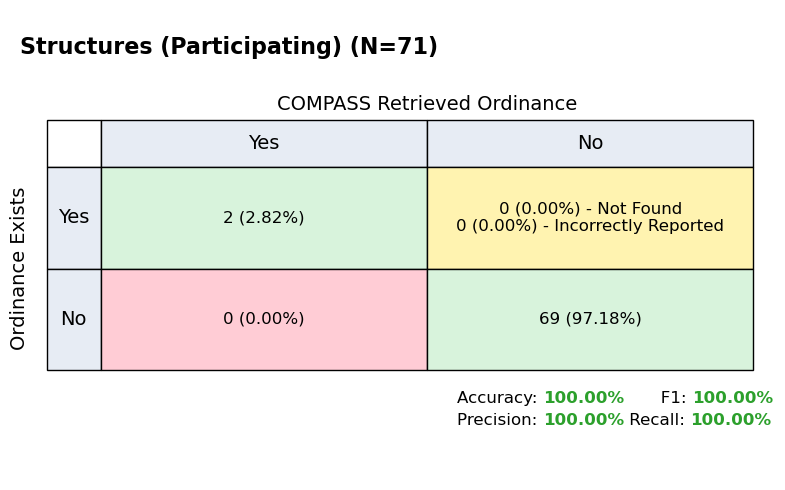

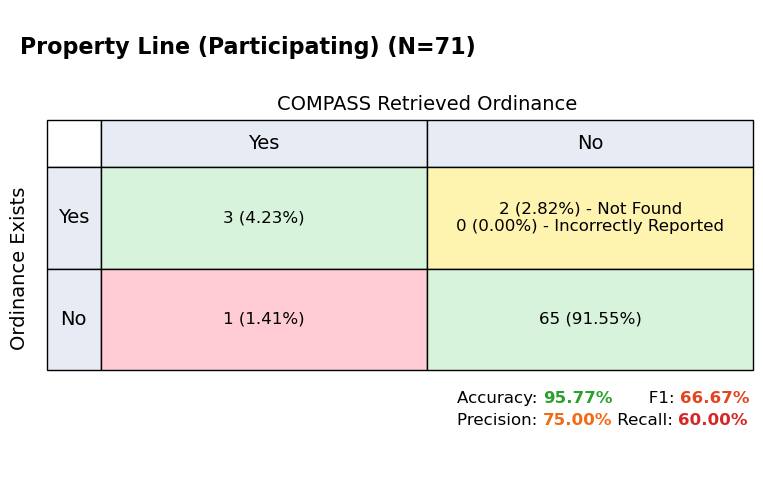

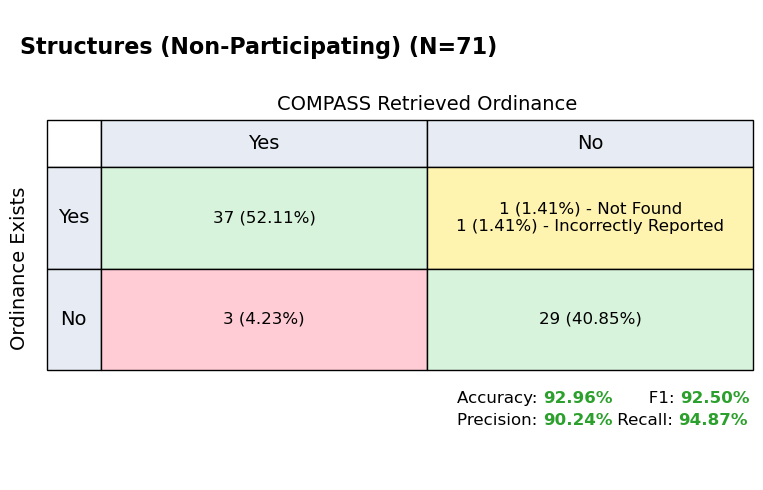

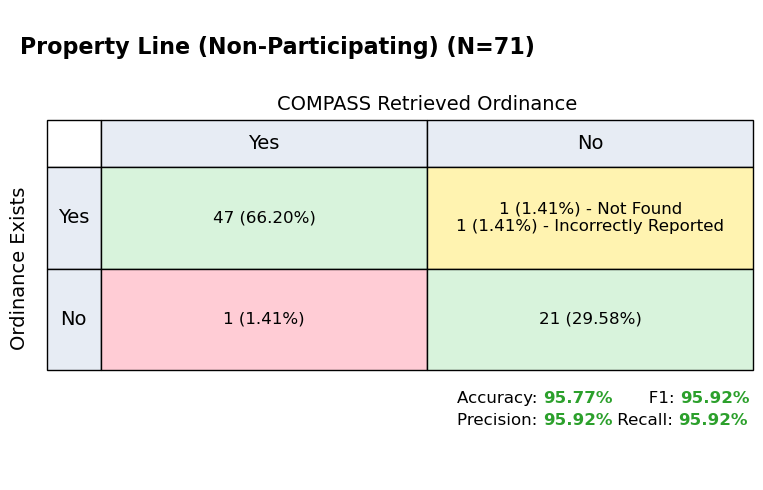

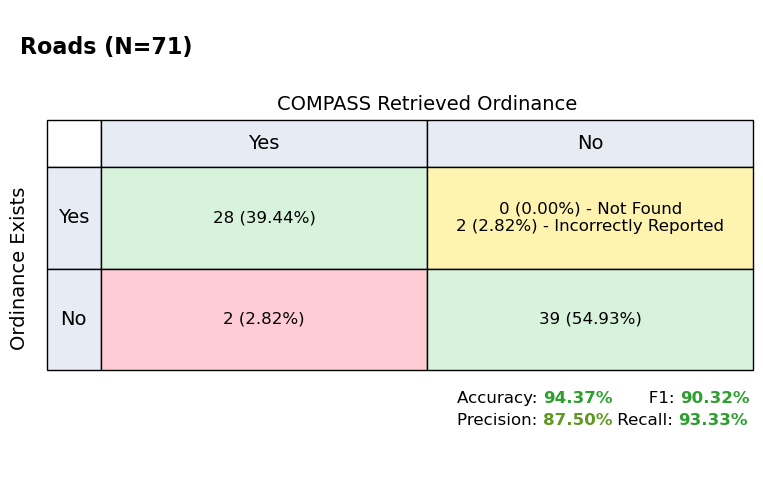

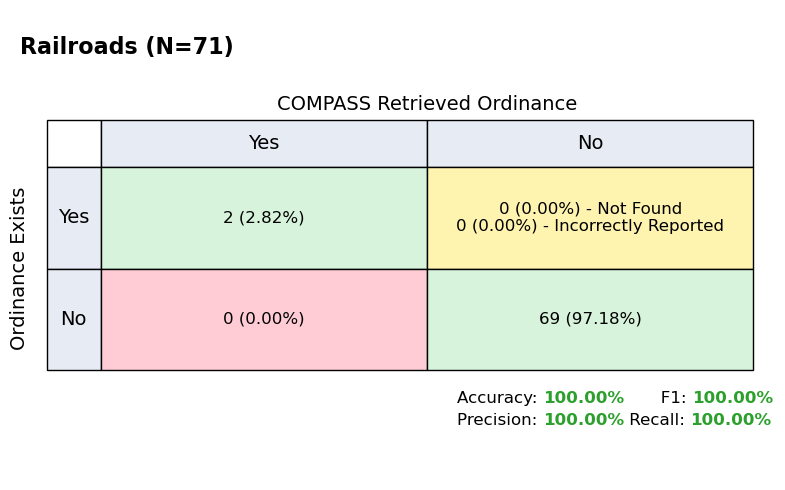

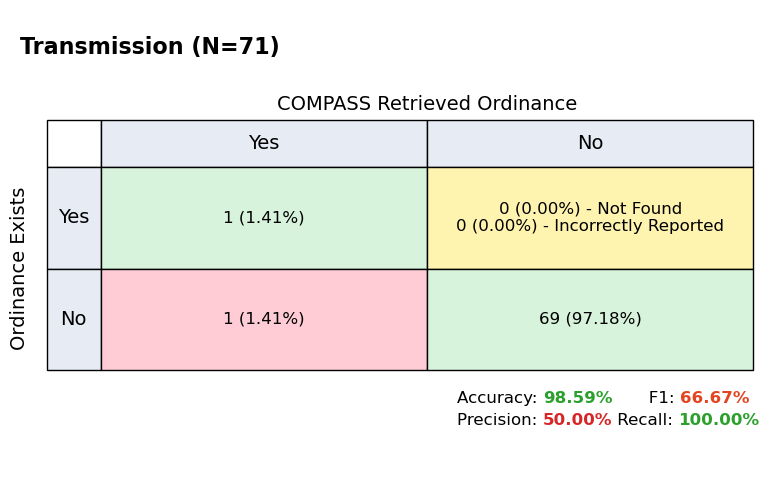

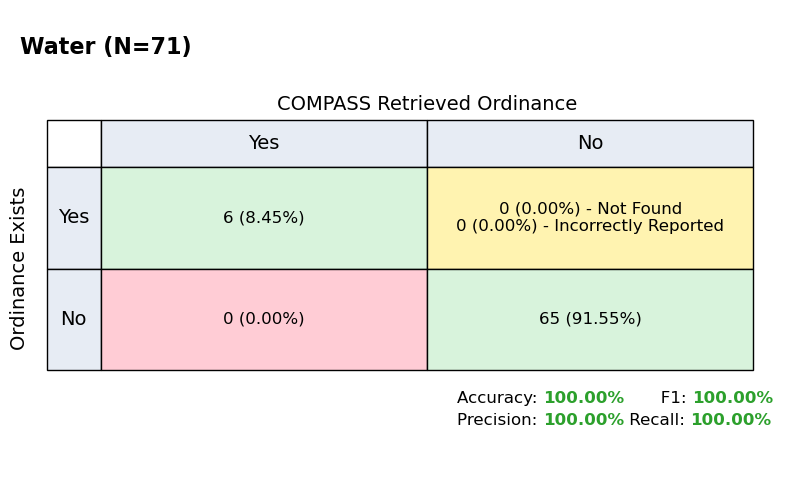

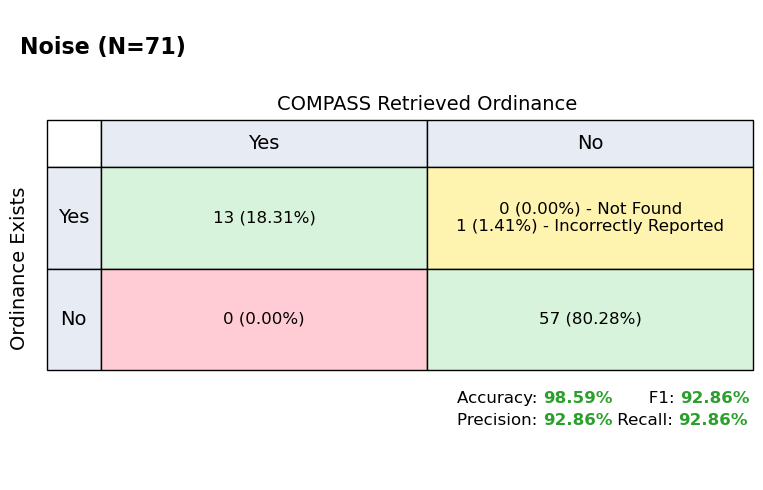

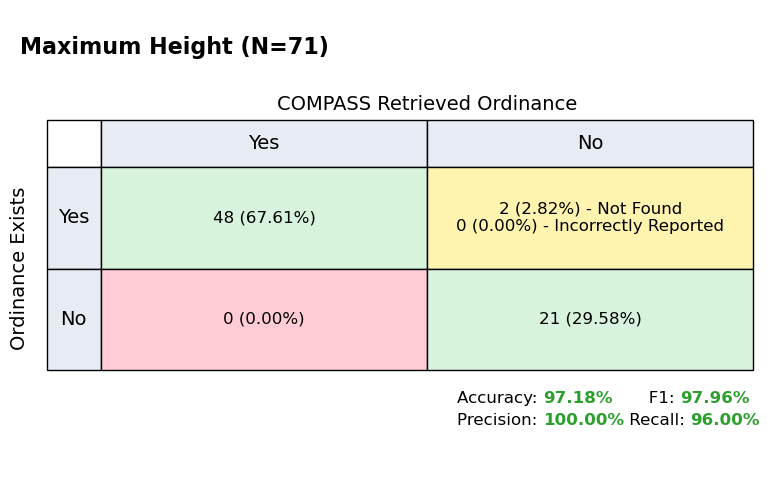

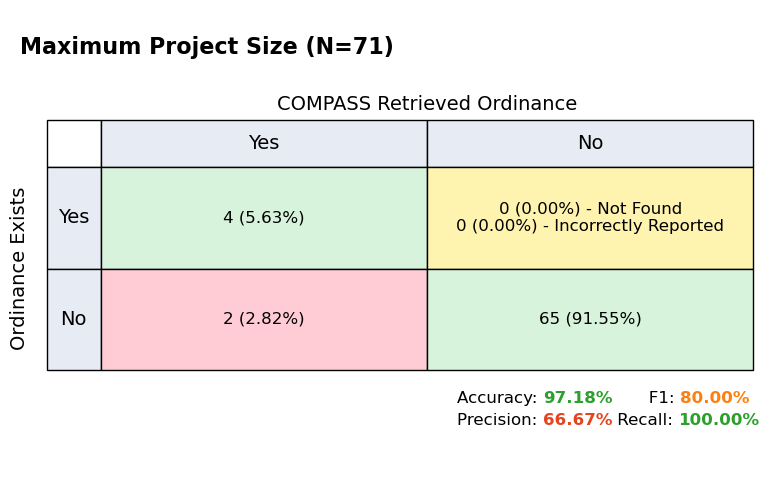

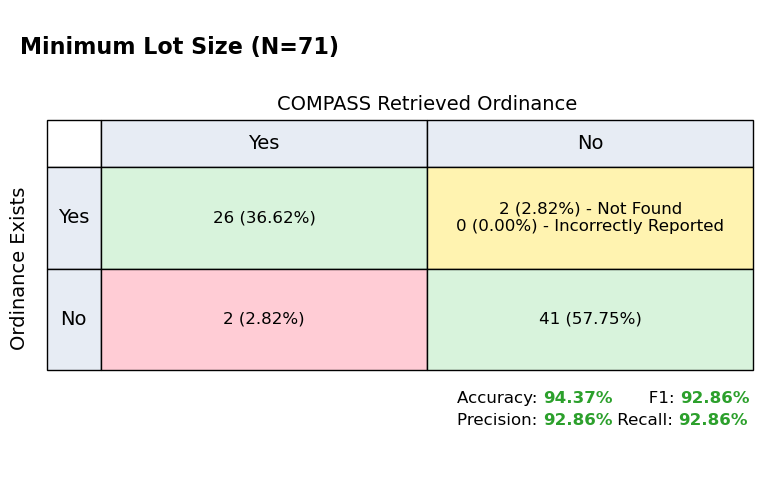

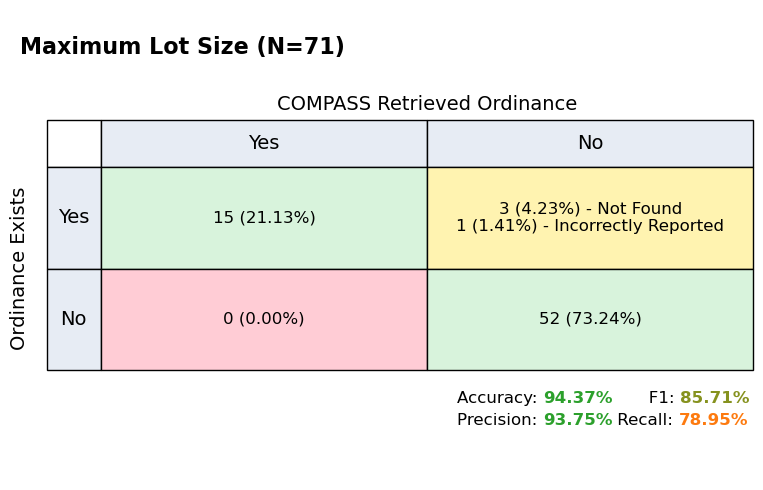

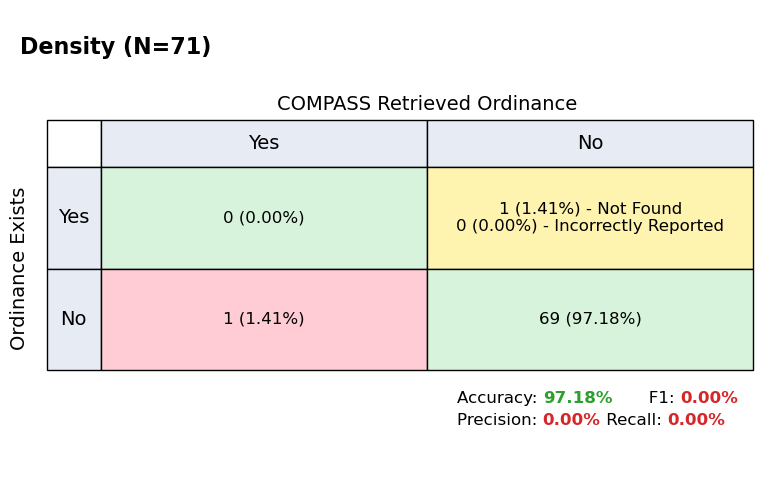

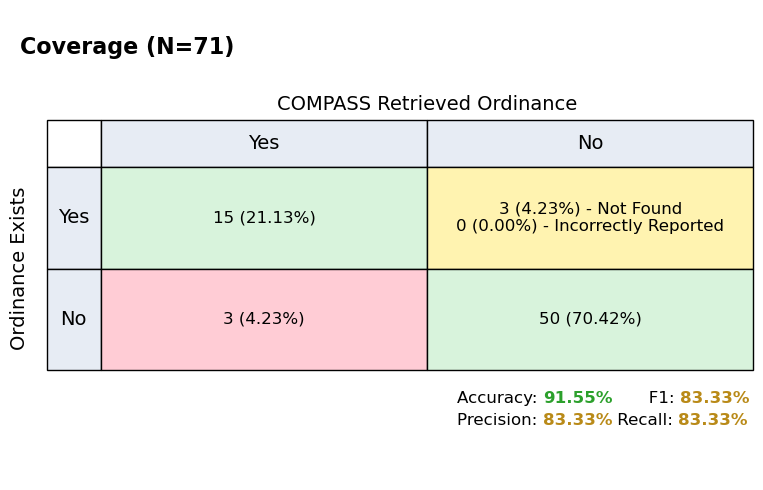

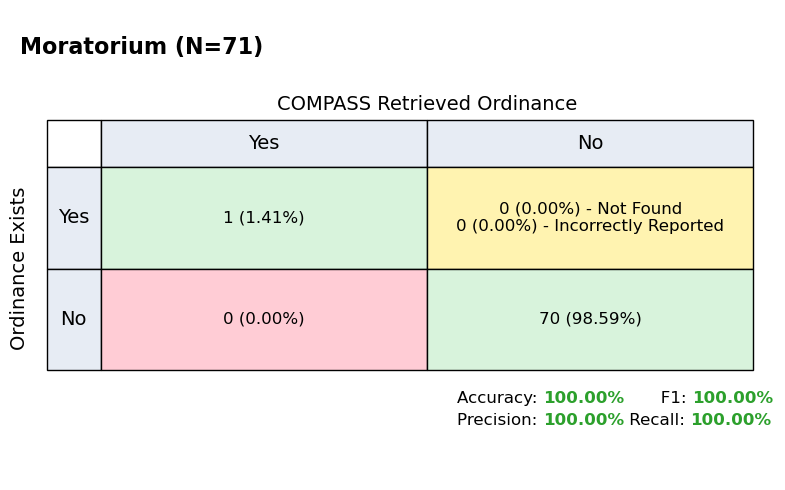

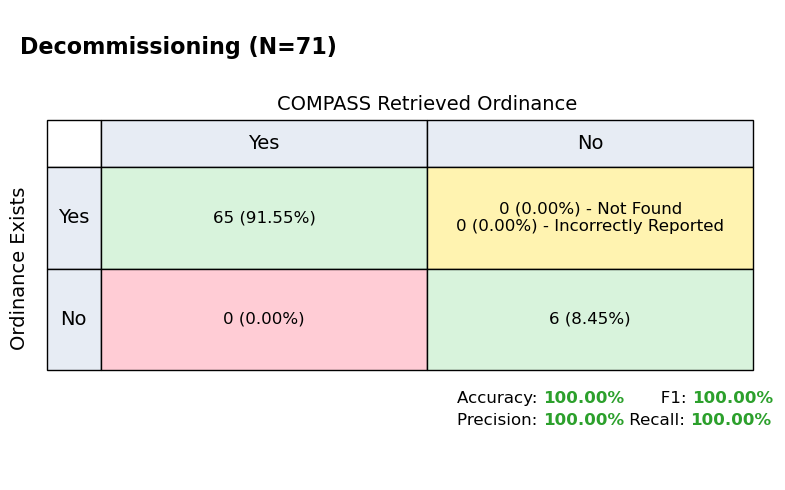

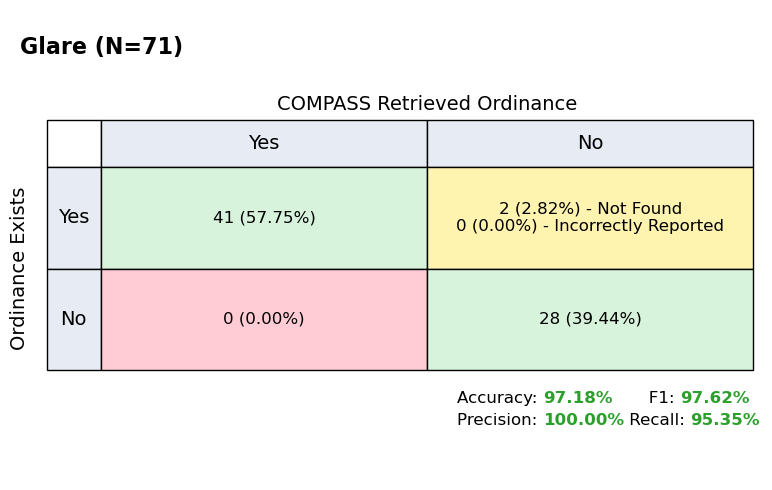

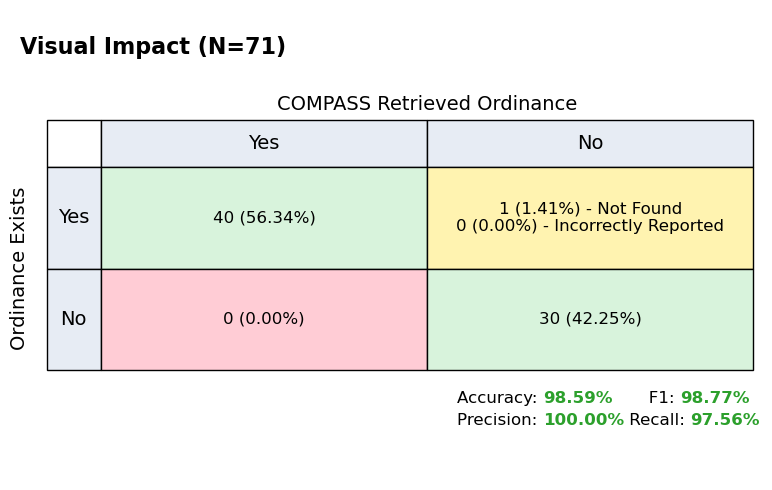

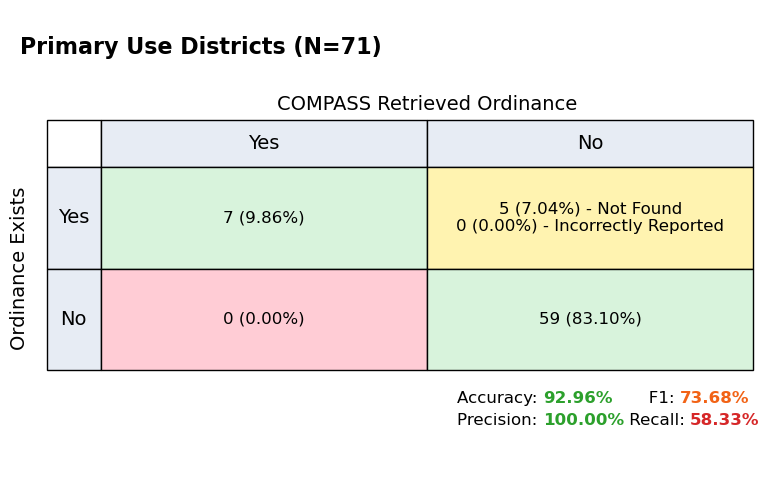

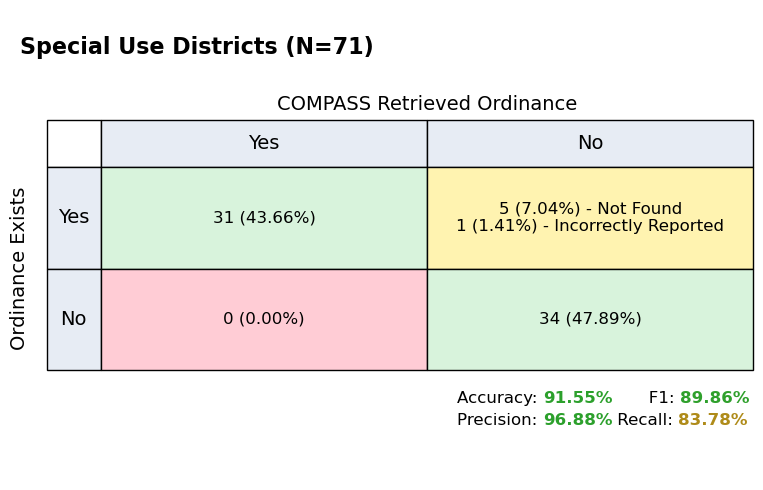

/home/ppinchuk/gitrepos/COMPASS/.pixi/envs/pdev/lib/python3.13/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


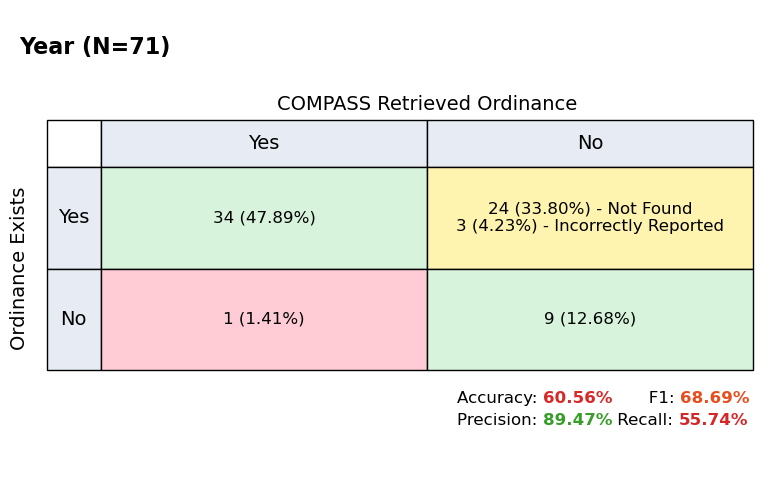

In [17]:
for feature in correct_doc_compare["feature"].unique():
    data = correct_doc_compare[correct_doc_compare["feature"] == feature]
    plot_out_fn = f"solar_validation_{feature}.png"
    plot_out_fn = (
        plot_out_fn.replace(" ", "_").replace("(", "").replace(")", "")
    )
    with contextlib.suppress(IndexError):
        plot_compass_confusion_matrix_from_data(
            data,
            score_cats,
            title=feature.title(),
            truth_labels_col=truth_labels_col,
            out_fp=plots_out_dir / plot_out_fn,
            color_scores=True,
        )